# Assignment 4
### Do three of four.

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [5]:
df=pd.read_csv('/Users/graceegeorge/DS5030_public_repo/data/mn_police_use_of_force.csv')
df.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [6]:
df['injury_na']=df['subject_injury'].isna()
# df

In [7]:
pd.crosstab(df['injury_na'],df['race'],normalize='columns')

race,Asian,Black,Native American,Other / Mixed Race,Pacific Islander,White
injury_na,,,,,,
False,0.364341,0.240847,0.280612,0.590244,0.0,0.246405
True,0.635659,0.759153,0.719388,0.409756,1.0,0.753595


In [8]:
race_injury=df.loc[:,['race','injury_na']].groupby('race').value_counts()
race_injury

race                injury_na
Asian               True           82
                    False          47
Black               True         5806
                    False        1842
Native American     True          564
                    False         220
Other / Mixed Race  False         121
                    True           84
Pacific Islander    True            6
White               True         2358
                    False         771
Name: count, dtype: int64

In [9]:
estimates=[]
for i in range(2500):
    x=df.sample(frac=1,replace=True)
    estimate=x.loc[:,['race','injury_na']].groupby('race').mean()
    estimates.append(estimate)
new_df=pd.concat([row for row in estimates],axis=1).T
new_df
    




race,Asian,Black,Native American,Other / Mixed Race,Pacific Islander,White
injury_na,0.637795,0.761607,0.710968,0.500000,1.0,0.754476
injury_na,0.634921,0.755353,0.712010,0.441558,1.0,0.751351
injury_na,0.615942,0.759494,0.728426,0.420765,1.0,0.760050
injury_na,0.657658,0.765717,0.707447,0.407821,1.0,0.748414
injury_na,0.624161,0.755678,0.743687,0.377551,1.0,0.753276
...,...,...,...,...,...,...
injury_na,0.575758,0.761793,0.704518,0.396825,1.0,0.752369
injury_na,0.568345,0.757361,0.724138,0.440909,1.0,0.752030
injury_na,0.657895,0.758964,0.740548,0.455446,1.0,0.753063
injury_na,0.584000,0.757877,0.716080,0.372642,1.0,0.759755


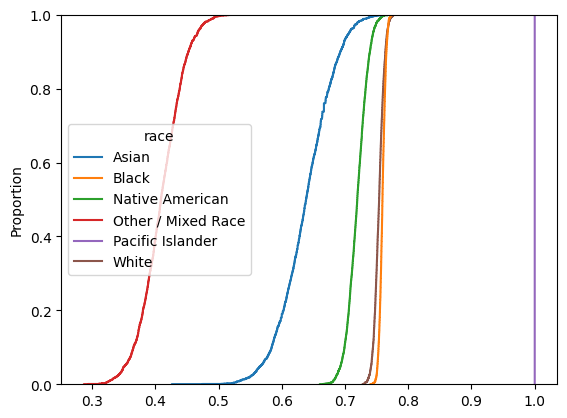

In [10]:
# Used AI for help debugging
sns.ecdfplot(new_df)
plt.show()

/var/folders/p9/9vqlyg213v3b9h9zrksgz6z00000gn/T/ipykernel_16561/2454411781.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(new_df)


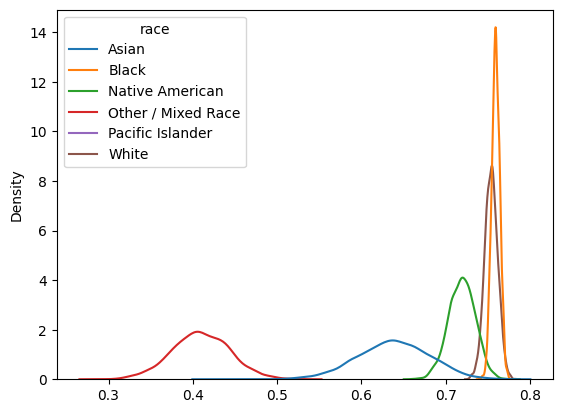

In [11]:
sns.kdeplot(new_df)
plt.show()

The sampling distrubution of the other/mixed race category and the Asian category seem to have lower proportions of na injury values compared to the other races. The distributions of Native Americans ,white people, and black people  look pretty similar and overlap. I found it intersting that the ecdf for the pacific islander group is a straight line a 100%. I wonder if this has to do with there being less pacific islanders in the population, so there will be less in the sample.

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data. Pick a variable and a statistic to compute (e.g. mean, median, variance, IQR)
- Use the `simulate` function from class to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [ ]:
df=pd.read_csv('/Users/graceegeorge/DS5030_public_repo/data/ames_prices.csv')
# df.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [14]:
def simulate(var, df, fcn, S=1000, plot=True): # Taking a sample the df data
                                                # applying the fcn function S times and 
                                                # makes plot of results
    ''' Bootstrap simulation code. '''    
    x = df[var]     #Sets the variable being bootstrapped

    estimates = []     # Sets an place to store bootrapped estimates
    for s in range(S): # Takes S samples
        x_s = x.sample(frac=1.0,replace=True) # Takes a sample of x's while replacing each time
        stat_s = fcn(x_s) #Takes the desired stat of each variable
        estimates.append(stat_s) # Stores each estimated stat in a list
    estimates = np.array(estimates) # Convert estimates list to numpy array

    ## or in one line, 

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # sets dimension of figures
        sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data') # Makes a kde of the data(not sampled)
        sns.kdeplot(estimates, ax = axes[1]).set(title='KDE of Computed Statistics') # Makes a kde of the bootstapimg
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--') # Data visualization
        sns.ecdfplot(estimates, ax = axes[2]).set(title='ECDF of Computed Statistics') # Makes an ecdf of the bootrapped stats
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--') # Data visualization
        plt.show() # Prints the graphs
        print(f'Variance of estimates is: {np.var(estimates)}') # Prints the variance of the estimates
        
    return estimates # Returns the list that stored the estimates

In [16]:
def stat(x):
    stat=np.mean(x)
    return stat

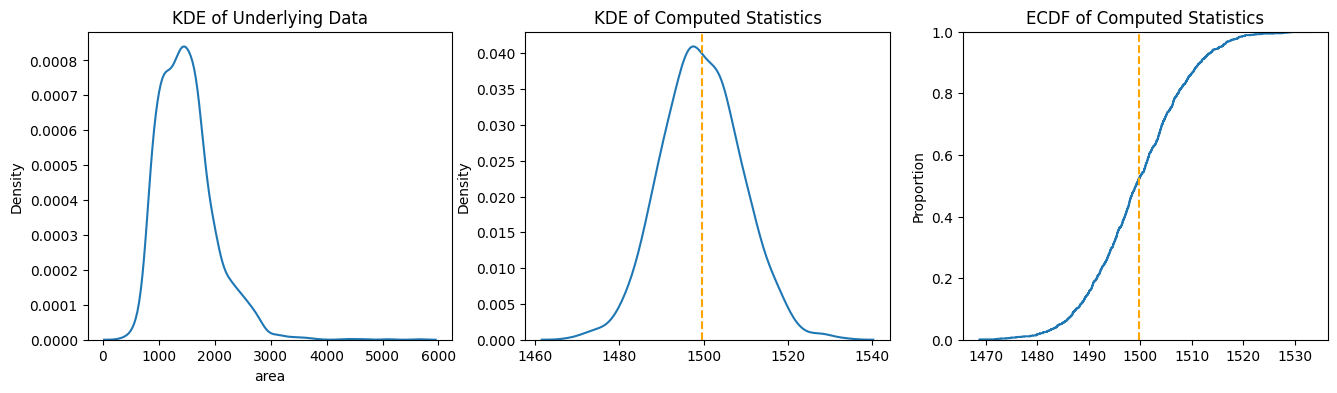

Variance of estimates is: 88.99472463745775


In [48]:
estimates=simulate('area',df,stat)


In [51]:
def interval(L,H,estimates,plot=True):
    if L<H:
        Lth=np.quantile(estimates,L)
        print(Lth)
        print(Lth)
        Hth=np.quantile(estimates,H)
        print()
    else:
        return   
    if plot:
        sns.kdeplot(estimates)
        plt.axvline(x=Lth,color='orange',linestyle="--") 
        plt.axvline(x=Hth,color='orange',linestyle="--") 
        print(f'Lower Bound:{Lth} \n Upper Bound:{Hth}')
    return Lth,Hth
        

1484.4453583617749
1484.4453583617749

Lower Bound:1484.4453583617749 
 Upper Bound:1515.324880546075


(np.float64(1484.4453583617749), np.float64(1515.324880546075))

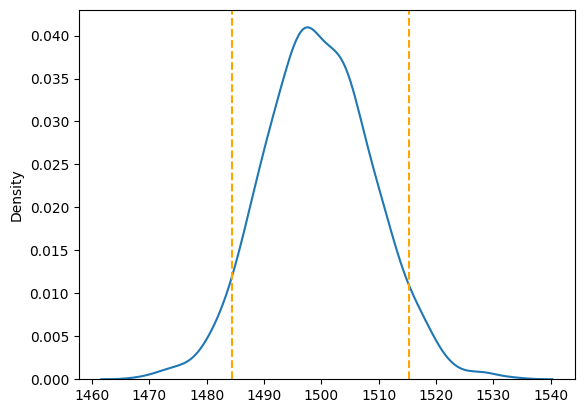

In [52]:
interval(.05,.95,estimates,plot=True)

We are 95% confident that the true value of average house area lies between 1485 and 1515.

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$, and make KDE plots of your results.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?